# Notebook I of more line ratios from saved maps from the PZ cubes

This is adapted from 01-02-yet-more-line-ratios. It calculates the Ar IV / Ar III ratio


In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from mpdaf.obj import Image
from zz_utils import get_image_raw, ROOT
import pyneb as pn
import regions
import pandas as pd

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/mpdaf/version.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
sns.set_context("talk")
sns.set_color_codes()

In [3]:
datadir = ROOT / "data"
figdir = ROOT / "figs"

## Can we get a He I density?

In [4]:
he1 = pn.RecAtom("He", 1)

In [5]:
dgrid = [1.0, 10.0, 100.0, 1000.0]
T0 = [11000, 13000, 18000]
he1.getEmissivity(tem=T0, den=dgrid, wave=5876) / he1.getEmissivity(
    tem=T0, den=dgrid, wave=6678
)

array([[3.52143762, 3.52143762, 3.52273521, 3.53264503],
       [3.5302056 , 3.5302056 , 3.5297992 , 3.53419086],
       [3.548379  , 3.548379  , 3.53549315, 3.49462034]])

In [6]:
he1.getEmissivity(tem=T0, den=dgrid, wave=4922) / he1.getEmissivity(
    tem=T0, den=dgrid, wave=5876
)

array([[0.09885076, 0.09885076, 0.09869156, 0.09562248],
       [0.1003275 , 0.1003275 , 0.09971259, 0.09410442],
       [0.1028182 , 0.1028182 , 0.10068853, 0.08872582]])

In [7]:
he1.getEmissivity(tem=T0, den=dgrid, wave=5048) / he1.getEmissivity(
    tem=T0, den=dgrid, wave=5876
)

array([[0.01533487, 0.01533487, 0.01539856, 0.01545717],
       [0.01685621, 0.01685621, 0.01687563, 0.01666441],
       [0.02038825, 0.02038825, 0.02011176, 0.01845355]])

In [56]:
im5048 = get_image_raw("he-i-5047-74")
im4921 = get_image_raw("he-i-492*")
im5016 = get_image_raw("he-i-501*")
im5876 = get_image_raw("he-i-5875-62")
imcont = get_image_raw("s-ii-671*", variant="cont")

In [9]:
i0, j0, w, h = 234, 200, 12, 8
bgbox = regions.RegionBoundingBox(
    iymin=j0 - h // 2,
    iymax=j0 + h // 2,
    ixmin=i0 - w // 2,
    ixmax=i0 + w // 2,
)
i0, j0, w, h = 250, 193, 8, 8
bsbox = regions.RegionBoundingBox(
    iymin=j0 - h // 2,
    iymax=j0 + h // 2,
    ixmin=i0 - w // 2,
    ixmax=i0 + w // 2,
)

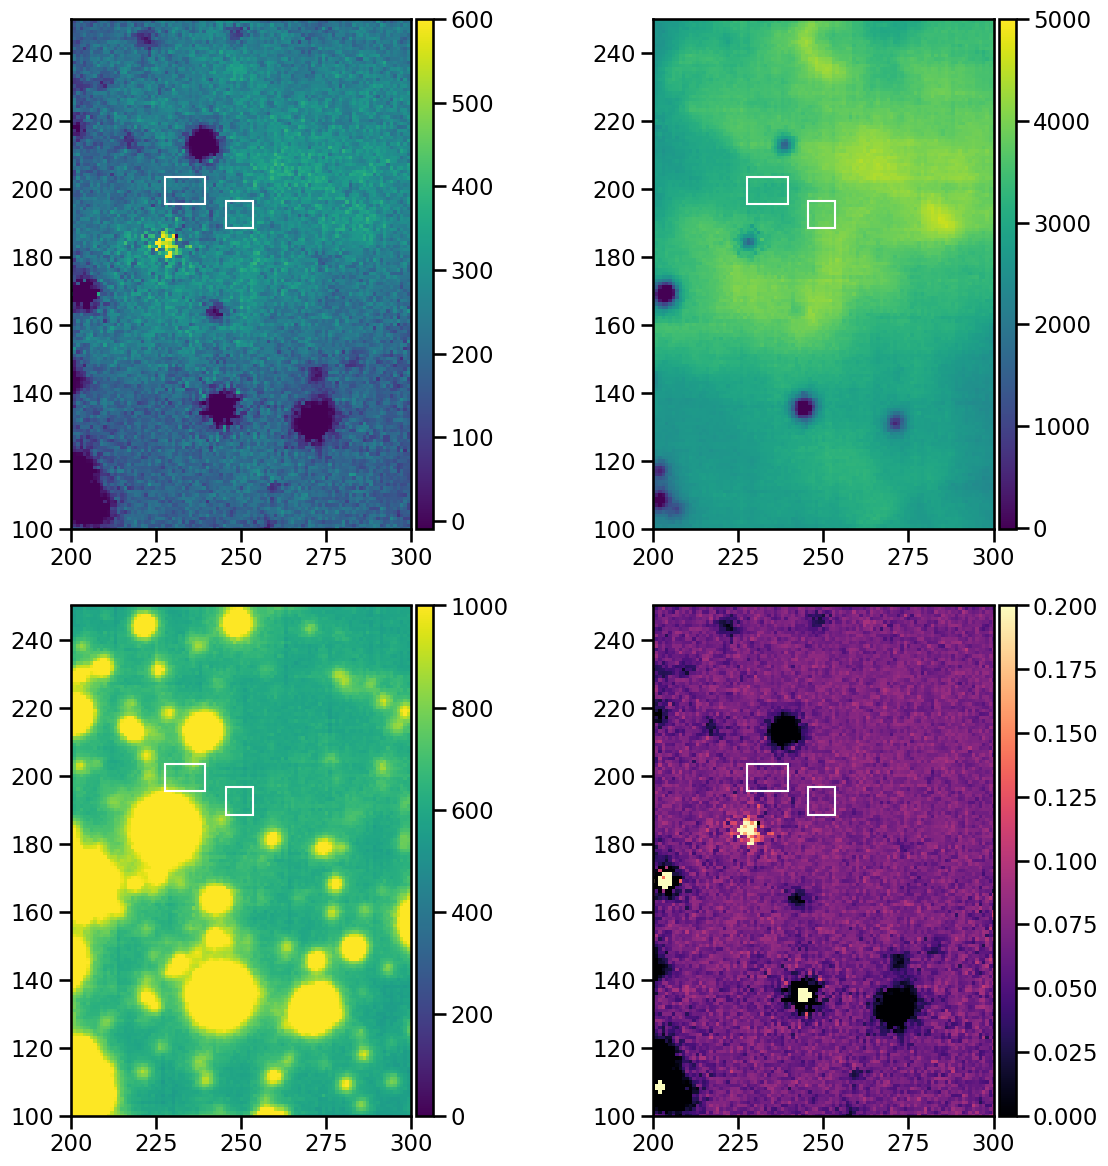

In [10]:
n = 1
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
im4921.rebin(n).plot(vmin=-10, vmax=600, ax=axes[0, 0], colorbar="v")
im5876.rebin(n).plot(vmin=-10, vmax=5000, ax=axes[0, 1], colorbar="v")
imcont.rebin(n).plot(vmin=0, vmax=1e3, ax=axes[1, 0], colorbar="v")
(im4921.rebin(n) / im5876.rebin(n)).plot(
    ax=axes[1, 1],
    vmin=0.0,
    vmax=0.2,
    cmap="magma",
    colorbar="v",
)
for ax in axes.flat:
    bsbox.plot(ax=ax, color="w")
    bgbox.plot(ax=ax, color="w")
    ax.set(
        xlim=[200, 300],
        ylim=[100, 250],
    )
fig.tight_layout()

In [11]:
def make_profile(im):
    return np.mean(im[yyslice, xxslice].data, axis=0)

In [12]:
xxslice = slice(None, None)
yyslice = slice(164, 204)  # original
# yyslice = slice(160, 210) # broader
# yyslice = slice(170, 200) # narrower
# yyslice = slice(180, 200) # top half ultra narrow
hei_profile = make_profile(im5876)
hei_5048_profile = make_profile(im5048)
hei_4921_profile = make_profile(im4921)
hei_5876_profile = make_profile(im5876)

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


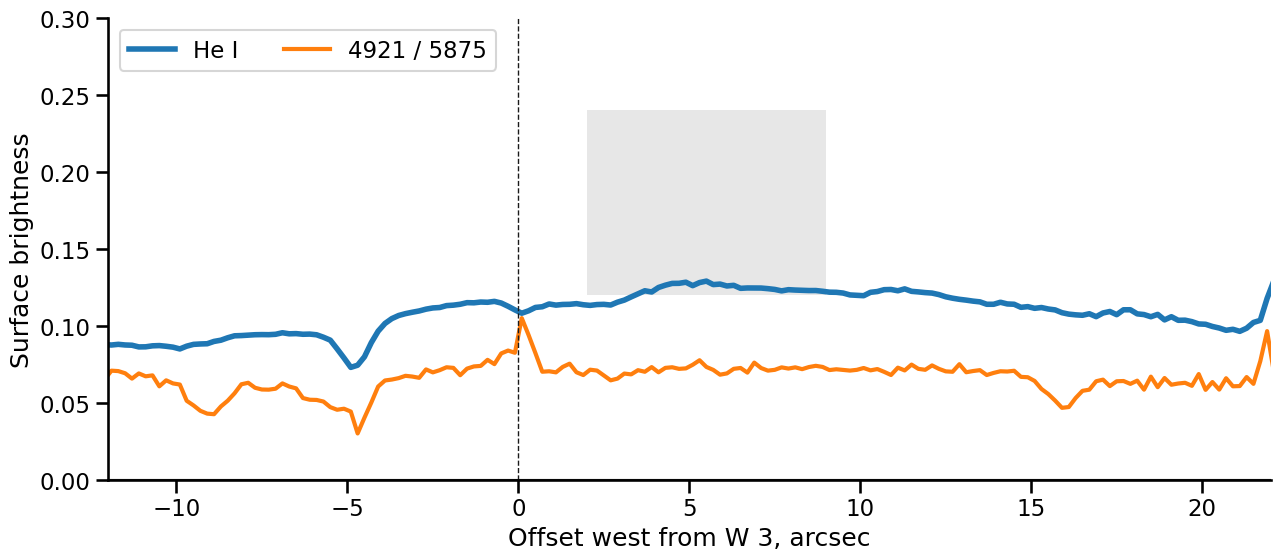

In [13]:
fig, ax = plt.subplots(figsize=(15, 6))
ix0 = 227.5
nx = len(hei_profile)
pos = (np.arange(nx) - ix0) * 0.2

ax.plot(pos, 0.1 * hei_5876_profile / np.median(hei_5876_profile), label="He I", lw=4)
ax.plot(pos, hei_4921_profile / hei_5876_profile, label="4921 / 5875", lw=3)

ax.axhline(0, color="k")

ax.axvline(0, color="k", lw=1, ls="dashed")
ax.axvspan(2.0, 9.0, 0.4, 0.8, color="k", alpha=0.1, linewidth=0, zorder=-100)
ax.legend(ncol=3, loc="upper left")

ax.set(
    xlabel="Offset west from W 3, arcsec",
    ylabel="Surface brightness",
    xlim=[-12, 22],
    ylim=[0, 0.3],
)
sns.despine()

In [14]:
bs_slices, _ = bsbox.get_overlap_slices(im5876.shape)
bg_slices, _ = bgbox.get_overlap_slices(im5876.shape)

In [15]:
bs_4921 = im4921[bs_slices].data.mean()
bs_5876 = im5876[bs_slices].data.mean()
bs_4921 / bs_5876

0.07170135475237852

In [16]:
bg_4921 = im4921[bg_slices].data.mean()
bg_5876 = im5876[bg_slices].data.mean()
bg_4921 / bg_5876

0.06881176997807568

These are all way lower than the theoretical values for reasonable temperatures.  Maybe the 5048 line is affected by underlying stellar absorption.

In [17]:
im9069 = Image(str(datadir / "ngc346-ZZ-siii-9069-correct.fits"))
im6731 = get_image_raw("s-ii-673*")
im6300 = get_image_raw("o-i-6300-30")

im_n_sii = Image(str(datadir / "ngc346-ZZ-N-sii.fits"))
im_T_siii = Image(str(datadir / "ngc346-ZZ-T-siii.fits"))



In [18]:
# yyslice = slice(164, 204) # original
# yyslice = slice(160, 210) # broader
# yyslice = slice(170, 200) # narrower
yyslice = slice(180, 200)  # top half ultra narrow
n_sii_profile = make_profile(im_n_sii)
T_siii_profile = make_profile(im_T_siii)
sii_profile = make_profile(im6731)
oi_profile = make_profile(im6300)
siii_profile = make_profile(im9069)

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


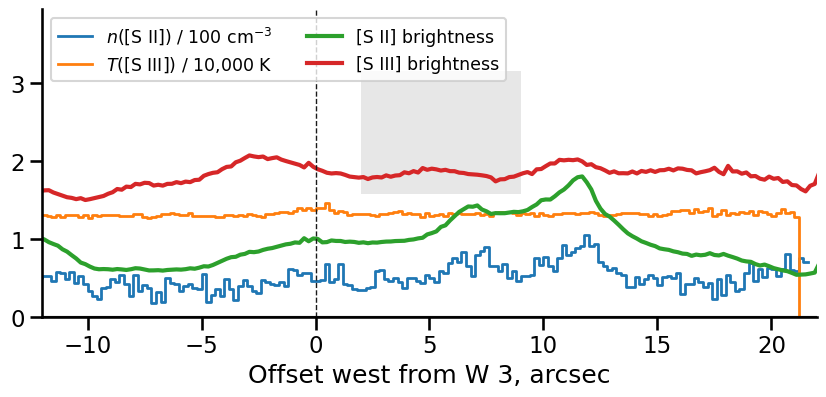

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ix0 = 227.5
nx = len(sii_profile)
pos = (np.arange(nx) - ix0) * 0.2
pos2 = (np.arange(len(siii_profile)) - ix0) * 0.2

ax.plot(
    pos, 0.01 * n_sii_profile, ds="steps-mid", label="$n$([S II]) / 100 cm$^{-3}$", lw=2
)
ax.plot(
    pos2, 0.0001 * T_siii_profile, ds="steps-mid", label="$T$([S III]) / 10,000 K", lw=2
)
ax.plot(
    pos, 1.0 * sii_profile / np.median(sii_profile), label="[S II] brightness", lw=3
)
ax.plot(
    pos2, 1.8 * siii_profile / np.median(siii_profile), label="[S III] brightness", lw=3
)

ax.axhline(0, color="k")

ax.axvline(0, color="k", lw=1, ls="dashed")
ax.axvspan(2.0, 9.0, 0.4, 0.8, color="k", alpha=0.1, linewidth=0, zorder=-100)
ax.legend(ncol=2, loc="upper left", fontsize="x-small")

ax.set(
    xlabel="Offset west from W 3, arcsec",
    xlim=[-12, 22],
    ylim=[0, 3.95],
)
sns.despine()
fig.savefig(figdir / "ngc346-ZZ-bow-shock-sii-siii-ne-te.pdf")

So the [S III] temperature is significantly larger than the [O III] temperature from the nebula. It is around 14000 K and has a drop towards W 3 coming from the east side, and then a step and a very constant region.  But the step occurs before the bow shock, so is probably unrelated.

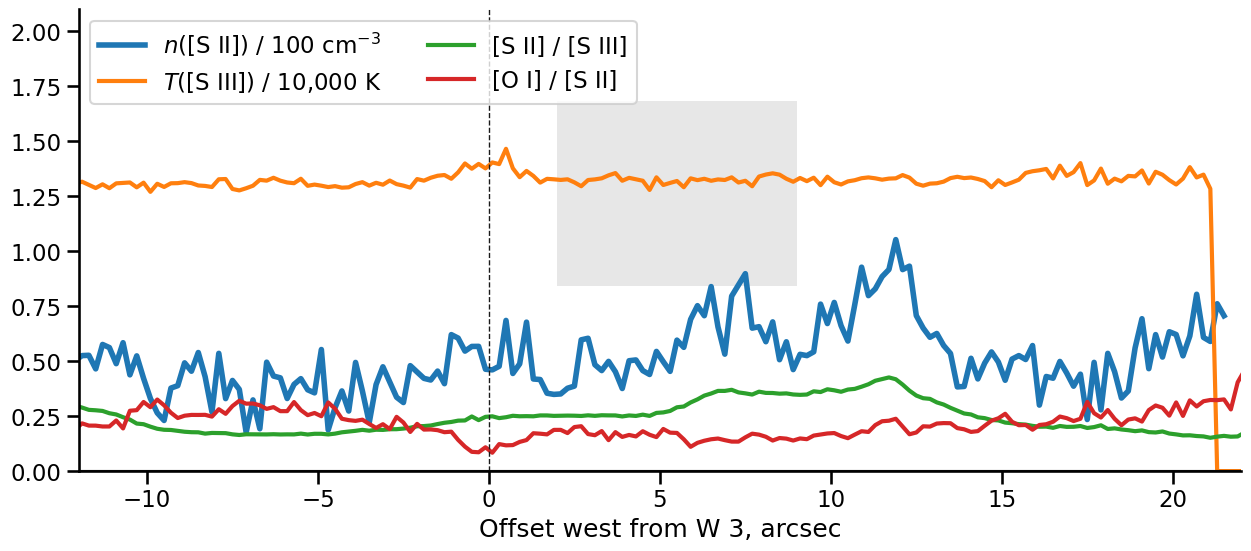

In [20]:
fig, ax = plt.subplots(figsize=(15, 6))
ix0 = 227.5
nx = len(sii_profile)
pos = (np.arange(nx) - ix0) * 0.2
pos2 = (np.arange(len(siii_profile)) - ix0) * 0.2

ax.plot(pos, 0.01 * n_sii_profile, label="$n$([S II]) / 100 cm$^{-3}$", lw=4)
ax.plot(pos2, 0.0001 * T_siii_profile, label="$T$([S III]) / 10,000 K", lw=3)
ax.plot(pos2, 1.0 * sii_profile / siii_profile, label="[S II] / [S III]", lw=3)
ax.plot(pos2, 4.0 * oi_profile / sii_profile, label="[O I] / [S II]", lw=3)


ax.axhline(0, color="k")

ax.axvline(0, color="k", lw=1, ls="dashed")
ax.axvspan(2.0, 9.0, 0.4, 0.8, color="k", alpha=0.1, linewidth=0, zorder=-100)
ax.legend(ncol=2, loc="upper left")

ax.set(
    xlabel="Offset west from W 3, arcsec",
    xlim=[-12, 22],
    ylim=[0, 2.1],
)
sns.despine()
fig.savefig(figdir / "ngc346-ZZ-bow-shock-sii-siii-ratio-ne-te.pdf")

In [60]:
imhei_c = Image(str(datadir / "ngc346-ZZ-hei-5875-correct.fits"))
imhi_c = Image(str(datadir / "ngc346-ZZ-hi-4861-correct.fits"))
imheii_c = Image(str(datadir / "ngc346-ZZ-heii-4686-correct.fits"))
imcont2 = get_image_raw("he-ii-46*", variant="cont")
imhei_r = get_image_raw("he-i-667*")
imhi_r = get_image_raw("h-i-656*")


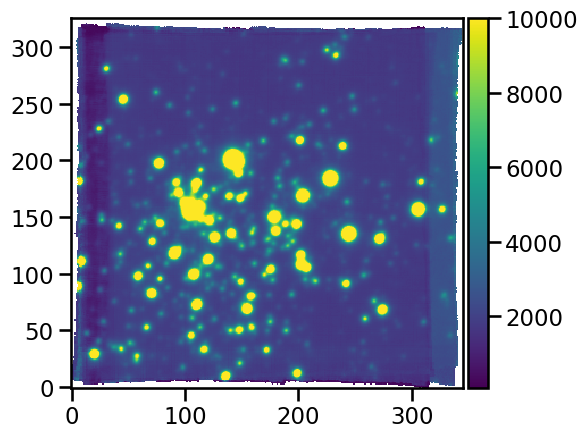

In [22]:
imcont2.plot(colorbar="v", vmax=10000)

In [61]:
m = imcont2.data > 10000.0
for im in imhei_c, imheii_c, imhi_c, imhei_r, imhi_r:
    im.mask = im.mask | m

In [62]:
# yyslice = slice(164, 204) # original
yyslice = slice(160, 210)  # broader
# yyslice = slice(170, 200) # narrower
# yyslice = slice(180, 200) # top half ultra narrow
hei_c_profile = make_profile(imhei_c)
hi_c_profile = make_profile(imhi_c)
heii_c_profile = make_profile(imheii_c)
cont_profile = make_profile(imcont2)
hei_r_profile = make_profile(imhei_r)
hi_r_profile = make_profile(imhi_r)

In [63]:
hei_r_profile / hi_r_profile

masked_array(data=[--, --, --, --, --, --, --, --, --,
                   0.008626747923309681, 0.008823353644014575,
                   0.007880685159428639, 0.008636304120588694,
                   0.009345509219731327, 0.009352017728828453,
                   0.009468377313874664, 0.009758083773073831,
                   0.0097006315091494, 0.009750880098911613,
                   0.00965433401928853, 0.009698474498817455,
                   0.009797848749080334, 0.009737818958595221,
                   0.009653179356813455, 0.009748472583047828,
                   0.009666100413622957, 0.009572455869058489,
                   0.009695774165374869, 0.009516852045048742,
                   0.009675637796863812, 0.009703815705440391,
                   0.00961178792271403, 0.009928010661050729,
                   0.009744034374795832, 0.009736774586867723,
                   0.009617234732858249, 0.009715545559717103,
                   0.009714396193897539, 0.009923180596144752,
    

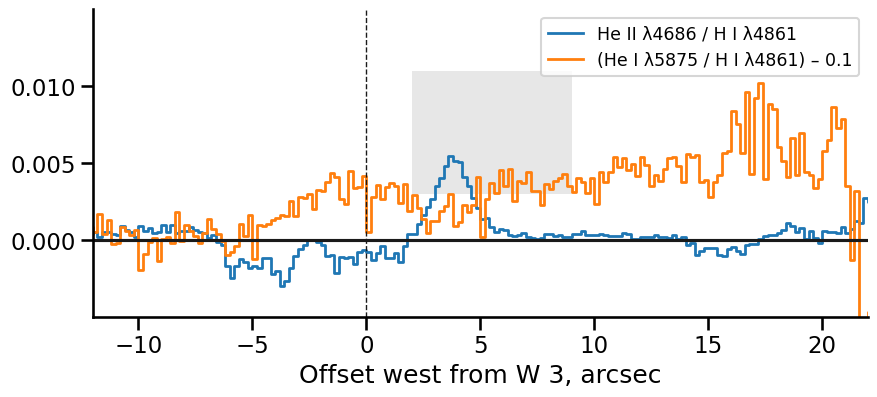

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
ix0 = 227.5
nx = len(hei_profile)
pos = (np.arange(nx) - ix0) * 0.2

ax.plot(
    pos,
    heii_c_profile / hi_c_profile,
    ds="steps-mid",
    label="He II λ4686 / H I λ4861",
    lw=2,
)
ax.plot(
    pos,
    hei_c_profile / hi_c_profile - 0.10,
    ds="steps-mid",
    label="(He I λ5875 / H I λ4861) – 0.1",
    lw=2,
)

ax.axhline(0, color="k")

ax.axvline(0, color="k", lw=1, ls="dashed")
ax.axvspan(2.0, 9.0, 0.4, 0.8, color="k", alpha=0.1, linewidth=0, zorder=-100)
ax.legend(ncol=1, loc="upper right", fontsize="x-small")
ax.set_yticks([0.0, 0.005, 0.010])
ax.set(
    xlabel="Offset west from W 3, arcsec",
    xlim=[-12, 22],
    ylim=[-0.005, 0.015],
)
sns.despine()
fig.savefig(figdir / "ngc346-ZZ-bow-shock-he-ratios.pdf")

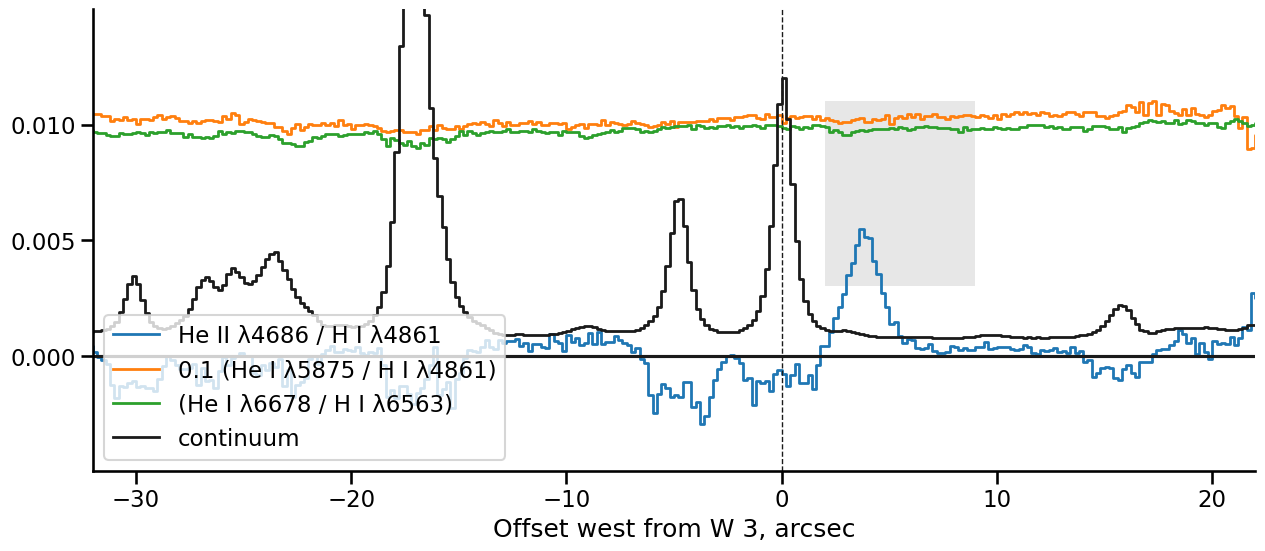

In [69]:
fig, ax = plt.subplots(figsize=(15, 6))
ix0 = 227.5
nx = len(hei_profile)
pos = (np.arange(nx) - ix0) * 0.2

ax.plot(
    pos,
    heii_c_profile / hi_c_profile,
    ds="steps-mid",
    label="He II λ4686 / H I λ4861",
    lw=2,
)
ax.plot(
    pos,
    0.1 * hei_c_profile / hi_c_profile,
    ds="steps-mid",
    label="0.1 (He I λ5875 / H I λ4861)",
    lw=2,
)
ax.plot(
    pos,
    # 10 * hei_r_profile / hi_r_profile - 0.10,
    hei_r_profile / hi_r_profile,
    ds="steps-mid",
    label="(He I λ6678 / H I λ6563)",
    lw=2,
)
ax.plot(
    pos,
    0.012 * cont_profile / np.max(cont_profile[np.abs(pos) < 10]),
    ds="steps-mid",
    label="continuum",
    lw=2,
    color="k",
)

ax.axhline(0, color="k")

ax.axvline(0, color="k", lw=1, ls="dashed")
ax.axvspan(2.0, 9.0, 0.4, 0.8, color="k", alpha=0.1, linewidth=0, zorder=-100)
ax.legend(ncol=1, loc="lower left")
ax.set_yticks([0.0, 0.005, 0.010])
ax.set(
    xlabel="Offset west from W 3, arcsec",
    xlim=[-32, 22],
    ylim=[-0.005, 0.015],
)
sns.despine()

These show the continuum as well, so we can see the PSF width of about 5 pixels, which is less thn the shell thickness of about 10 pixels.

In [27]:
im5518 = get_image_raw("cl-iii-5517-71")
im5538 = get_image_raw("cl-iii-5537-88")
imha = get_image_raw("h-i-656*")
imcont = get_image_raw("h-i-486*", variant="cont")

In [28]:
cl3 = pn.Atom("Cl", 3)
Rlo = cl3.getLowDensRatio(wave1=5518, wave2=5538)
Rhi = cl3.getHighDensRatio(wave1=5518, wave2=5538)
Rlo, Rhi

(1.4564515685984458, 0.2122339155754461)

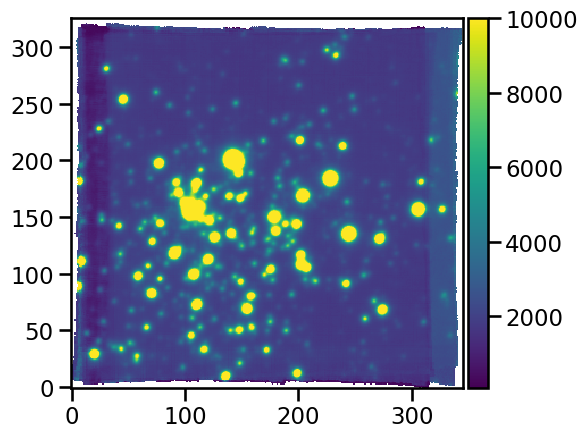

In [29]:
imcont2.plot(colorbar="v", vmax=10000)

In [30]:
def trim_edges(im, m):
    """Trim m pixels of each edge of image in place by setting mask"""
    im.mask[:m, :] = True
    im.mask[-m:, :] = True
    im.mask[:, :m] = True
    im.mask[:, -m:] = True
    return None


In [31]:
m = imcont.data > 10000
im5518.mask = im5518.mask | m
im5538.mask = im5538.mask | m
trim_edges(im5518, 20)
trim_edges(im5538, 20)
trim_edges(imcont, 20)

In [32]:
# shift5538 = 15.0
# shift5518 = 23.0
# im5538.data += shift5538
# im5518.data += shift5518

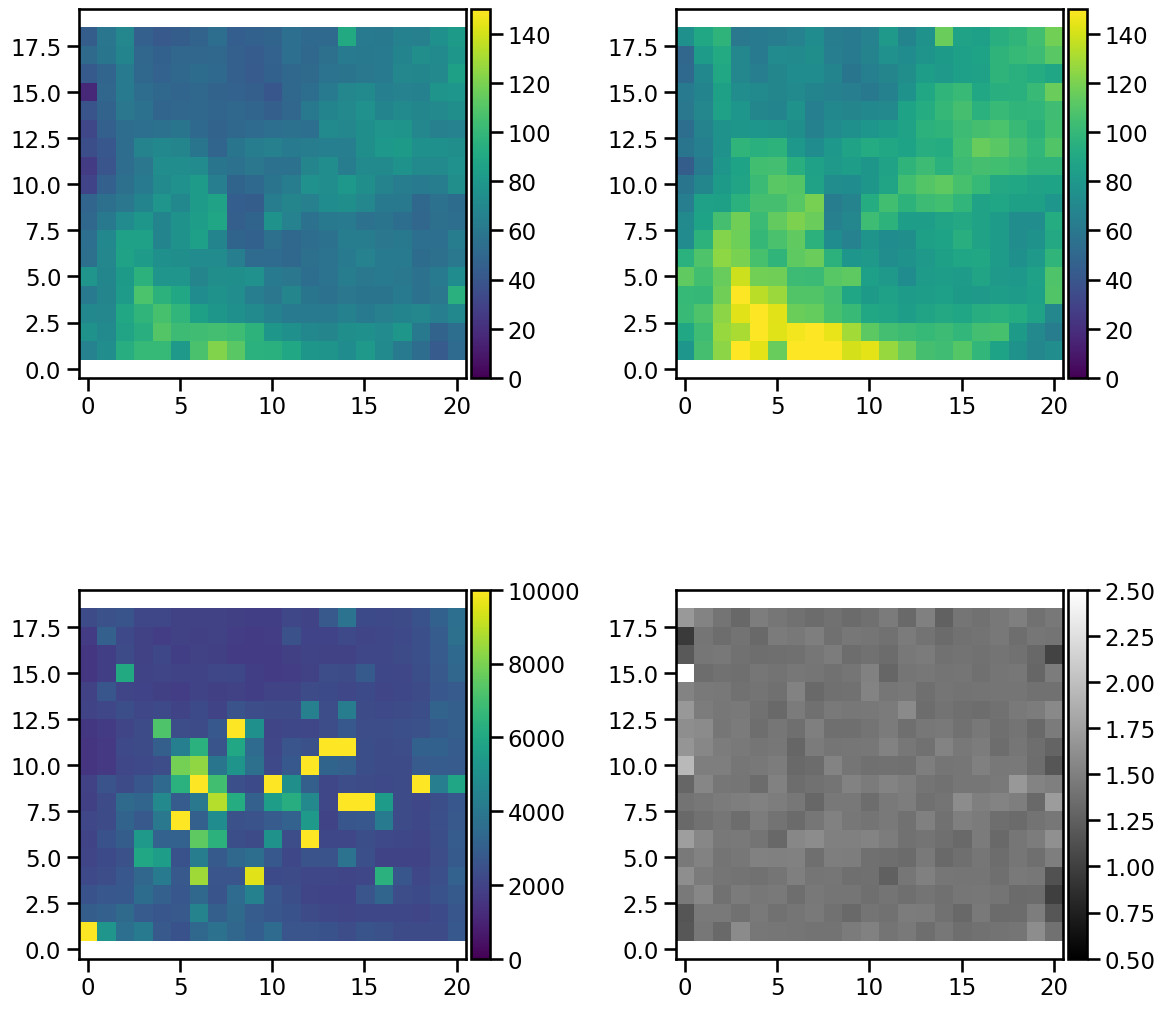

In [54]:
n = 16
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
im5538.rebin(n).plot(vmin=0, vmax=150, ax=axes[0, 0], colorbar="v")
im5518.rebin(n).plot(vmin=0, vmax=150, ax=axes[0, 1], colorbar="v")
imcont.rebin(n).plot(vmin=0, vmax=1e4, ax=axes[1, 0], colorbar="v")
(im5518.rebin(n) / im5538.rebin(n)).plot(
    ax=axes[1, 1],
    vmin=0.5,
    vmax=2.5,
    cmap="gray",
    colorbar="v",
)
fig.tight_layout()

Text(0.5, 0.98, 'Correlation between [Cl III] 5538 and 5518 brightness')

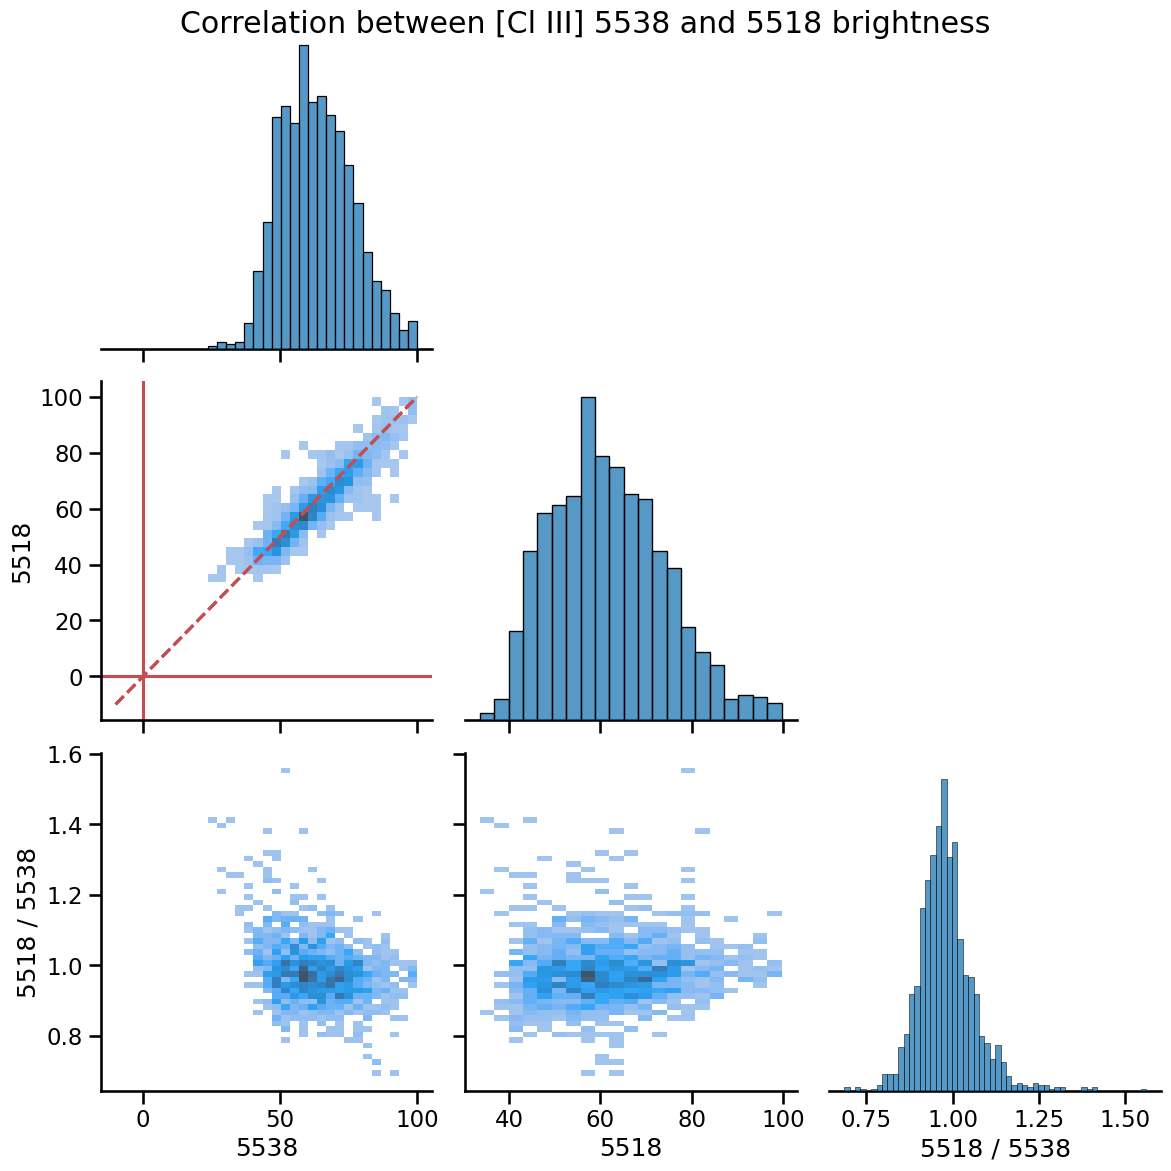

In [34]:
n = 8

imx = im5538.rebin(n)
imy = (im5518 / Rlo).rebin(n)

imin, imax = -10, 100
m = (imx.data < imax) & (imy.data < imax)
m = m & (imx.data > imin) & (imy.data > imin)
m = m & (imy.data / imx.data > -2) & (imy.data / imx.data < 4.0)
m = m & ~imx.mask & ~imy.mask
df = pd.DataFrame(
    {
        "5538": imx.data[m],
        "5518": imy.data[m],
        "5518 / 5538": imy.data[m] / imx.data[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)
g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(0.0, color="r")
g.axes[1, 0].plot([imin, imax], [imin, imax], "--", color="r")
g.axes[1, 0].plot([imin, imax], [imin, imax], "--", color="r")
g.fig.suptitle("Correlation between [Cl III] 5538 and 5518 brightness")

Text(0.5, 0.98, 'Correlation between [Cl III] 5538, 5518 sum and ratio')

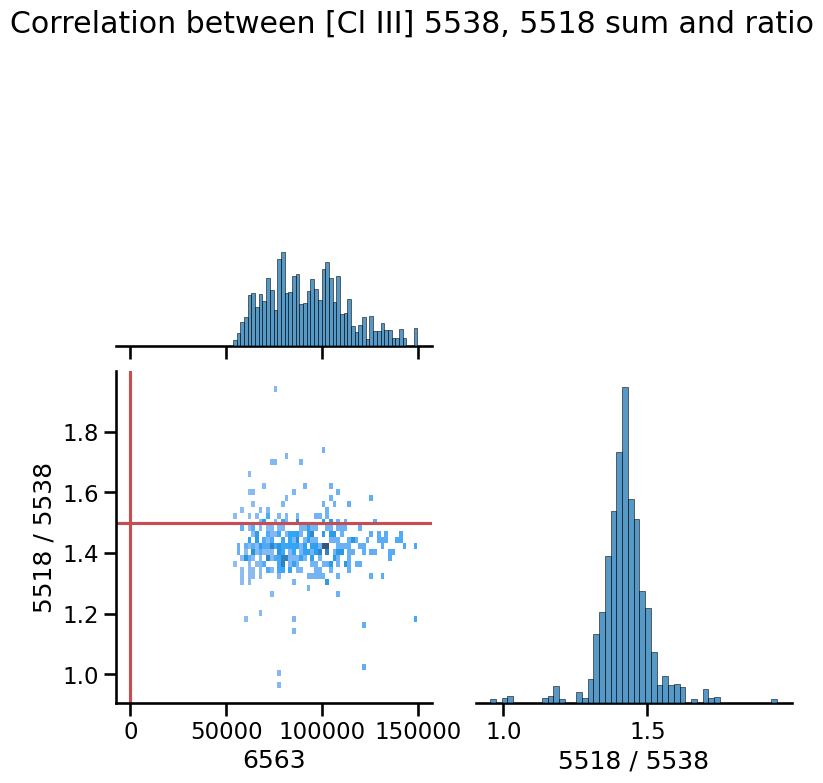

In [35]:
n = 16

imx = imha.rebin(n)
imy = im5518.rebin(n) / im5538.rebin(n)

imin, imax = -10, 100
m = (imy.data > 0.5) & (imy.data < 2.0)
m = m & (imx.data < 1.5e5)
m = m & ~imx.mask & ~imy.mask
df = pd.DataFrame(
    {
        "6563": imx.data[m],
        "5518 / 5538": imy.data[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(
        weights=imx.data[m],
        bins=50,
    ),
    diag_kws=dict(
        weights=imx.data[m],
        bins=50,
    ),
)
g.axes[1, 0].axvline(0.0, color="r")
g.axes[1, 0].axhline(1.5, color="r")
g.fig.suptitle("Correlation between [Cl III] 5538, 5518 sum and ratio")

Text(0.5, 0.98, 'Correlation between [Cl III] 5538 / 5518 ratio and Ha brightness')

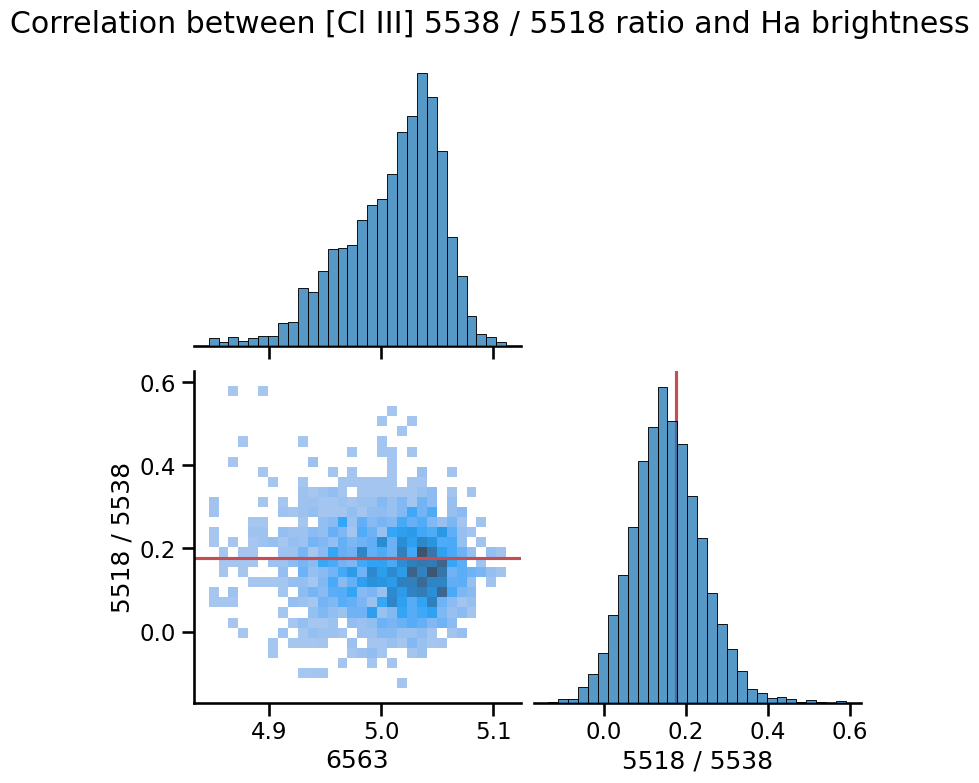

In [36]:
xslice, yslice = slice(230, 300), slice(144, 245)

n = 2

imx = imha[yslice, xslice].rebin(n)
imy = im5518[yslice, xslice].rebin(n) / im5538[yslice, xslice].rebin(n)

imin, imax = -10, 100
m = (imy.data > 0.15) & (imy.data < 15.0)
m = m & (imx.data < 1.5e5)
m = m & ~imx.mask & ~imy.mask
df = pd.DataFrame(
    {
        "6563": np.log10(imx.data[m]),
        "5518 / 5538": np.log10(imy.data[m]),
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(
        weights=imx.data[m],
        bins=30,
    ),
    diag_kws=dict(
        weights=imx.data[m],
        bins=30,
    ),
)
g.axes[1, 0].axhline(np.log10(1.5), color="r")
g.axes[1, 1].axvline(np.log10(1.5), color="r")


g.fig.suptitle("Correlation between [Cl III] 5538 / 5518 ratio and Ha brightness")

In [37]:
m = ~im5518[yslice, xslice].mask
npix = m.sum()
y = im5518[yslice, xslice].data[m]
x = im5538[yslice, xslice].data[m]
w = imha[yslice, xslice].data[m]

# unweighted
ym = y.mean()
xm = x.mean()
R1 = ym / xm
dR1 = np.sqrt((y.var() / ym**2 + x.var() / xm**2) / (npix - 1))

# weighted
ymw = np.average(y, weights=w)
xmw = np.average(x, weights=w)
R2 = ymw / xmw
dR2 = np.sqrt(
    (
        np.average(((y - ymw) / ymw) ** 2, weights=w)
        + np.average(((x - ymw) / xmw) ** 2, weights=w)
    )
    / (npix - 1)
)
f"Unweighted R = {R1:.4f} +/- {dR1:.4f}; Weighted R = {R2:.4f} +/- {dR2:.4f}"

'Unweighted R = 1.4208 +/- 0.0044; Weighted R = 1.4194 +/- 0.0067'

In [38]:
cl3 = pn.Atom("Cl", 3)
Rlo = cl3.getLowDensRatio(wave1=5518, wave2=5538)
Rhi = cl3.getHighDensRatio(wave1=5518, wave2=5538)
Rlo, Rhi

(1.4564515685984458, 0.2122339155754461)

In [39]:
cl3.getTemDen([1.415, 1.42, 1.425], tem=12000, wave1=5518, wave2=5538)

array([95.1912234 , 79.89084733, 62.78554824])

In [40]:
e5518 = cl3.getEmissivity(tem=12000, den=[1, 10, 100, 1000], wave=5518)
e5538 = cl3.getEmissivity(tem=12000, den=[1, 10, 100, 1000], wave=5538)
e5518 / e5538

array([1.44396914, 1.44119942, 1.41416716, 1.19711876])

In [41]:
e5518 = cl3.getEmissivity(tem=15000, den=[1, 10, 100, 1000], wave=5518)
e5538 = cl3.getEmissivity(tem=15000, den=[1, 10, 100, 1000], wave=5538)
e5518 / e5538

array([1.4285447 , 1.42601153, 1.40124273, 1.19934751])

In [42]:
e5518 = cl3.getEmissivity(tem=8000, den=[1, 10, 100, 1000], wave=5518)
e5538 = cl3.getEmissivity(tem=8000, den=[1, 10, 100, 1000], wave=5538)
e5518 / e5538

array([1.4658756 , 1.46262646, 1.43103423, 1.18496487])

We can only get an average density since the noise overwhelms any spatial variations

In [43]:
cliii_ratios = [R2 - dR2, R2, R2 + dR2]

In [48]:
cl3.getTemDen(cliii_ratios, tem=13000, wave1=5518, wave2=5538)

array([85.31678524, 67.04974743, 45.20353656])

In [49]:
cl3.getTemDen(cliii_ratios, tem=13400, wave1=5518, wave2=5538)

array([85.31678524, 60.09449924, 37.11590441])

So [Cl III] density is 70 +/- 25